In [16]:
import pandas as pd
import re
from datetime import datetime
import unicodedata

In [17]:
import pandas as pd
import re
from datetime import datetime

def parse_whatsapp(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
    
    data = []
    current_msg = ""
    current_sender = None
    current_dt = None
    
    # Tuned regex for your format: [MM/DD/YY, HH:MM:SS PM] Sender: message
    pattern = r'^\[(\d{1,2}/\d{1,2}/\d{2,4}),\s*(\d{1,2}:\d{2}:\d{2})\s*([AP]M)\]\s*(.+?):\s*(.*)$'
    
    for line in lines:
        line = line.strip()
        if not line:
            continue
        
        match = re.match(pattern, line)
        if match:
            # Save previous message
            if current_msg and current_sender and current_dt is not None:
                data.append({
                    'datetime': current_dt,
                    'sender': current_sender.strip(),
                    'message': current_msg.strip()
                })
            
            date_str, time_str, ampm, sender, msg = match.groups()
            dt_str = f"{date_str} {time_str} {ampm}"
            try:
                current_dt = datetime.strptime(dt_str, "%m/%d/%y %H:%M:%S %p")
            except ValueError:
                print(f"⚠️ Date parse failed: {dt_str}")
                continue
            current_sender = sender
            current_msg = msg
        else:
            # Continuation of previous message (sticker omitted, multi-line, etc.)
            if current_msg:
                current_msg += " " + line
    
    # Last message
    if current_msg and current_sender and current_dt is not None:
        data.append({
            'datetime': current_dt,
            'sender': current_sender.strip(),
            'message': current_msg.strip()
        })
    
    df = pd.DataFrame(data)
    if not df.empty:
        df = df.sort_values('datetime').reset_index(drop=True)
    return df

# ====================== RUN IT ======================
file_path = r"C:\Users\08300\Downloads\WhatsApp Chat - Sylvia Pierce\_chat.txt"
df = parse_whatsapp(file_path)

print("✅ Rows parsed:", len(df))
print(df.head(10))
print("\nSenders:", df['sender'].unique())

✅ Rows parsed: 161966
             datetime         sender  \
0 2022-05-27 05:21:39  Sylvia Pierce   
1 2022-05-27 05:21:39  Sylvia Pierce   
2 2022-05-27 07:46:42        Chris H   
3 2022-05-27 07:47:17  Sylvia Pierce   
4 2022-05-27 08:04:02        Chris H   
5 2022-05-27 08:07:25  Sylvia Pierce   
6 2022-05-27 08:07:30  Sylvia Pierce   
7 2022-05-27 08:07:41  Sylvia Pierce   
8 2022-05-27 08:38:48        Chris H   
9 2022-05-27 08:54:28  Sylvia Pierce   

                                             message  
0  ‎Messages and calls are end-to-end encrypted. ...  
1                         hello! is it Chris number?  
2  Hii it’s Chris😊 ‎[5/27/22, 7:47:14 PM] Sylvia ...  
3                                            awesome  
4  Yeah it actually works. Finally we can talk mo...  
5                                            no much  
6                        I'm finally on my vacations  
7         planning to start watching stranger things  
8  Ohh sweet. Oh I love that show season 4

In [18]:
# First, identify her messages (customize the name match)
her_name_pattern = "Sylvia"   # or whatever partial name works
df['is_her'] = df['sender'].str.contains(her_name_pattern, case=False, na=False)

def normalize(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    # Remove accents for better matching
    import unicodedata
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii')
    return text

def has_keyword(text, keywords):
    norm = normalize(text)
    return any(kw in norm for kw in keywords)

# Keyword lists - expand these based on your actual chat
horny_keywords = [
    'horny', 'wet', 'turned on', 'aroused', 'throbbing', 'hot for', 'tesão',
    'com tesão', 'excitada', 'excitado', 'molhada', 'afim', 'tesuda'
]

orgasm_keywords = [
    'came', 'cum', 'orgasm', 'orgasmed', 'gozei', 'gozou', 'gozando', 
    'orgasmo', 'vim', 'senti', 'acabei', 'gozei gostoso', 'tive um orgasmo'
]

# Apply flags
df['horny_flag'] = df.apply(
    lambda row: has_keyword(row['message'], horny_keywords) and row['is_her'], 
    axis=1
)

df['orgasm_flag'] = df['message'].apply(
    lambda x: has_keyword(x, orgasm_keywords)
)

print("Flags added!")
print(df[['datetime', 'sender', 'is_her', 'horny_flag', 'orgasm_flag']].head(20))
print("\nHorny messages found:", df['horny_flag'].sum())
print("Orgasm mentions found:", df['orgasm_flag'].sum())

Flags added!
              datetime         sender  is_her  horny_flag  orgasm_flag
0  2022-05-27 05:21:39  Sylvia Pierce    True       False        False
1  2022-05-27 05:21:39  Sylvia Pierce    True       False        False
2  2022-05-27 07:46:42        Chris H   False       False        False
3  2022-05-27 07:47:17  Sylvia Pierce    True       False        False
4  2022-05-27 08:04:02        Chris H   False       False        False
5  2022-05-27 08:07:25  Sylvia Pierce    True       False        False
6  2022-05-27 08:07:30  Sylvia Pierce    True       False        False
7  2022-05-27 08:07:41  Sylvia Pierce    True       False        False
8  2022-05-27 08:38:48        Chris H   False       False         True
9  2022-05-27 08:54:28  Sylvia Pierce    True       False        False
10 2022-05-27 08:54:34  Sylvia Pierce    True       False         True
11 2022-05-27 08:54:48  Sylvia Pierce    True       False        False
12 2022-05-27 08:54:54  Sylvia Pierce    True       False       

                            horny_dt                      orgasm_dt  \
count                            315                            315   
mean   2024-04-20 10:49:23.517460224  2024-04-20 14:23:55.304762112   
min              2022-06-01 02:40:14            2022-06-01 08:39:26   
25%       2023-05-21 02:21:40.500000     2023-05-21 02:37:01.500000   
50%              2024-01-01 12:28:10            2024-01-02 08:02:34   
75%              2025-04-17 08:52:05     2025-04-17 09:10:59.500000   
max              2026-06-25 12:30:34            2026-06-25 12:32:09   
std                              NaN                            NaN   

         delta_min        hour     weekday  
count   315.000000  315.000000  315.000000  
mean    214.529788    6.542857    2.914286  
min       1.000000    1.000000    0.000000  
25%       8.741667    3.000000    1.000000  
50%      34.216667    7.000000    3.000000  
75%     149.066667   10.000000    5.000000  
max    1433.866667   12.000000    6.000000  


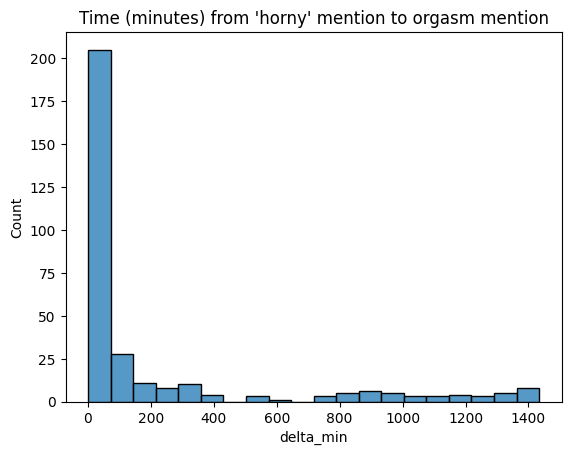

In [19]:
from datetime import timedelta

deltas = []
horny_rows = df[df['horny_flag']].index

for idx in horny_rows:
    subsequent = df.iloc[idx+1:]
    next_orgasm = subsequent[subsequent['orgasm_flag']].head(1)
    if not next_orgasm.empty:
        delta = (next_orgasm.iloc[0]['datetime'] - df.iloc[idx]['datetime']).total_seconds() / 60.0
        if 1 <= delta <= 1440:  # reasonable window: 1 min to 24 hours
            deltas.append({
                'horny_dt': df.iloc[idx]['datetime'],
                'orgasm_dt': next_orgasm.iloc[0]['datetime'],
                'delta_min': delta,
                'hour': df.iloc[idx]['datetime'].hour,
                'weekday': df.iloc[idx]['datetime'].weekday()
            })

deltas_df = pd.DataFrame(deltas)
if not deltas_df.empty:
    print(deltas_df.describe())
    # Visuals
    import matplotlib.pyplot as plt
    import seaborn as sns
    sns.histplot(deltas_df['delta_min'], bins=20)
    plt.title("Time (minutes) from 'horny' mention to orgasm mention")
    plt.show()
else:
    print("No paired events found yet — expand keywords or check longer chat.")

Paired events: 315
                            horny_dt                      orgasm_dt  \
count                            315                            315   
mean   2024-04-20 10:49:23.517460224  2024-04-20 14:23:55.304762112   
min              2022-06-01 02:40:14            2022-06-01 08:39:26   
25%       2023-05-21 02:21:40.500000     2023-05-21 02:37:01.500000   
50%              2024-01-01 12:28:10            2024-01-02 08:02:34   
75%              2025-04-17 08:52:05     2025-04-17 09:10:59.500000   
max              2026-06-25 12:30:34            2026-06-25 12:32:09   
std                              NaN                            NaN   

         delta_min        hour     weekday  
count   315.000000  315.000000  315.000000  
mean    214.529788    6.542857    2.914286  
min       1.000000    1.000000    0.000000  
25%       8.741667    3.000000    1.000000  
50%      34.216667    7.000000    3.000000  
75%     149.066667   10.000000    5.000000  
max    1433.866667   12.00

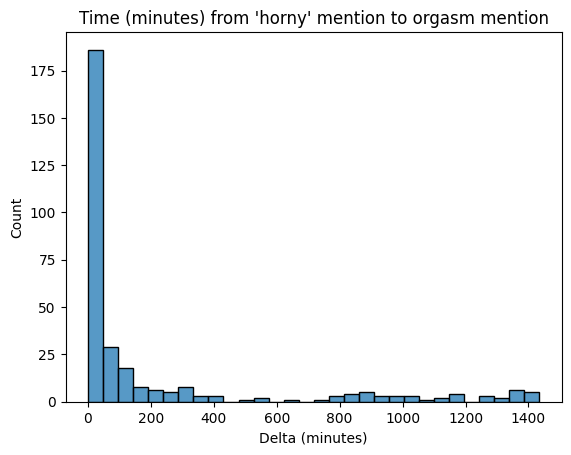

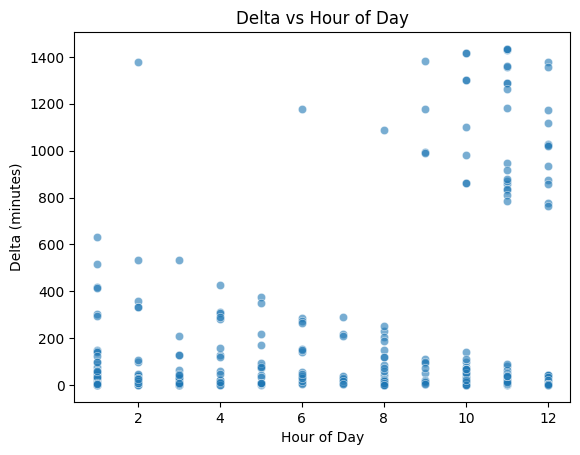

In [24]:
from datetime import timedelta
import pandas as pd

deltas = []
horny_rows = df[df['horny_flag']].index.tolist()

for idx in horny_rows:
    subsequent = df.iloc[idx+1:]
    next_orgasm = subsequent[subsequent['orgasm_flag']].head(1)
    if not next_orgasm.empty:
        delta = (next_orgasm.iloc[0]['datetime'] - df.iloc[idx]['datetime']).total_seconds() / 60.0
        if 1 <= delta <= 1440:   # 1 minute to 24 hours
            row = df.iloc[idx]
            deltas.append({
                'horny_dt': row['datetime'],
                'orgasm_dt': next_orgasm.iloc[0]['datetime'],
                'delta_min': delta,
                'hour': row['datetime'].hour,
                'weekday': row['datetime'].weekday()   # 0=Mon ... 6=Sun
            })

deltas_df = pd.DataFrame(deltas)

print("Paired events:", len(deltas_df))
if not deltas_df.empty:
    print(deltas_df.describe())
    print("\nCorrelation matrix:")
    print(deltas_df[['delta_min', 'hour', 'weekday']].corr())
    
    # Visuals
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    sns.histplot(deltas_df['delta_min'], bins=30)
    plt.title("Time (minutes) from 'horny' mention to orgasm mention")
    plt.xlabel("Delta (minutes)")
    plt.show()
    
    sns.scatterplot(data=deltas_df, x='hour', y='delta_min', alpha=0.6)
    plt.title("Delta vs Hour of Day")
    plt.xlabel("Hour of Day")
    plt.ylabel("Delta (minutes)")
    plt.show()
else:
    print("No pairs found.")

In [21]:
deltas_df = pd.DataFrame(deltas)
print(deltas_df['delta_minutes'].describe())

count     361.000000
mean      187.255540
std       366.143789
min         0.050000
25%         4.333333
50%        24.866667
75%       120.583333
max      1433.866667
Name: delta_minutes, dtype: float64


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
print(deltas_df[['delta_min', 'hour', 'weekday']].corr())

# Visuals
sns.scatterplot(data=deltas_df, x='hour', y='delta_min')
plt.title("Delta vs Hour of Day")
plt.show()

sns.boxplot(data=deltas_df, x='weekday', y='delta_min')
plt.title("Delta by Day of Week")
plt.show()

KeyError: "None of [Index(['delta_min', 'hour', 'weekday'], dtype='object')] are in the [columns]"